# Analysis: Revenue and Transaction Trends
This notebook covers the exploratory data analysis (EDA) of the bank's transaction and revenue data.
We will explore time-series trends to understand monthly revenue patterns and seasonality.
Furthermore, we will perform an ANOVA test to determine if there are statistically significant 
differences in revenue generation across different branches.



In [1]:
import pandas as pd
import sqlite3
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create connection
conn = sqlite3.connect('../../data/warehouse/enterprise_dw.db')
vis_dir = '../../notebooks/eda/visualizations'
os.makedirs(vis_dir, exist_ok=True)



## Data Loading
We will extract daily transaction volumes as a proxy for revenue generation activities,
aggregating them at the monthly level.



In [2]:
query_ts = """
SELECT 
    strftime('%Y-%m', transaction_date) as txn_month,
    SUM(amount) as total_volume,
    COUNT(transaction_id) as txn_count
FROM fact_transactions
GROUP BY txn_month
ORDER BY txn_month
"""
df_ts = pd.read_sql_query(query_ts, conn)
for col in df_ts.columns:
    if df_ts[col].dtype == 'object':
        try: df_ts[col] = pd.to_numeric(df_ts[col])
        except: pass
df_ts.fillna(0, inplace=True)
df_ts['txn_month'] = pd.to_datetime(df_ts['txn_month'])
df_ts.head()



,txn_month,total_volume,txn_count
0,2025-07-01,2.087109e+06,19512
1,2025-08-01,4.474978e+06,42791
2,2025-09-01,4.268998e+06,41106
3,2025-10-01,4.473851e+06,42292
4,2025-11-01,4.265093e+06,40736


## Time-Series Analysis: Monthly Trends and Seasonality
Visualizing the total transaction volume over time allows us to spot overall growth trends 
and seasonal spikes (e.g., end-of-year or holiday season surges).



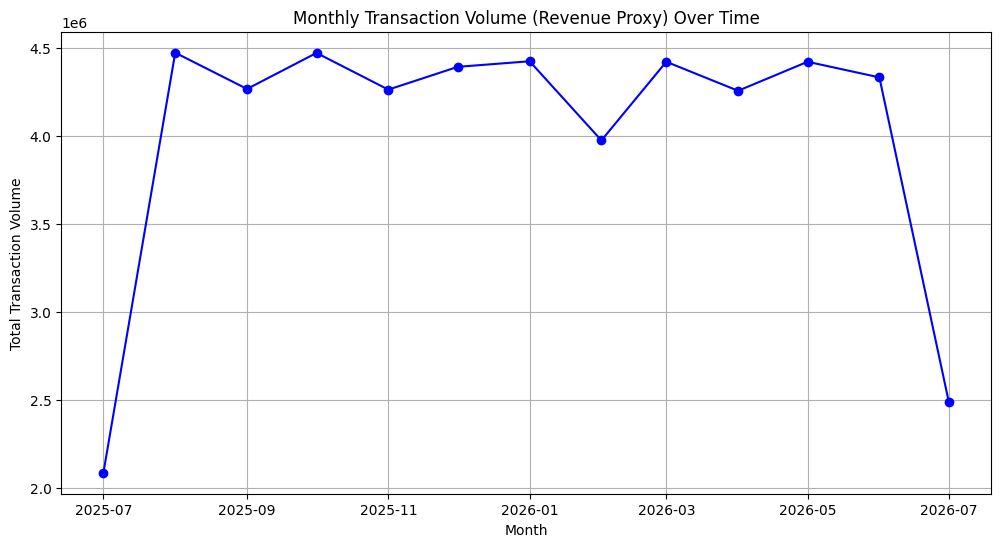

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts['txn_month'], df_ts['total_volume'], marker='o', linestyle='-', color='b')
plt.title('Monthly Transaction Volume (Revenue Proxy) Over Time')
plt.xlabel('Month')
plt.ylabel('Total Transaction Volume')
plt.grid(True)
plt.savefig(f'{vis_dir}/revenue_time_series.png', bbox_inches='tight')
plt.show()



**Business Interpretation:**
The time-series plot helps the executive team understand if the bank's transaction volume is growing over time. Seasonal peaks can indicate periods where increased system capacity or targeted marketing campaigns might be most effective. Any sudden dips should be investigated for potential operational issues or market downturns.



## Statistical Testing: ANOVA Test (Revenue by Branch)
We want to understand if there is a significant difference in the transaction volumes (revenue) 
generated by accounts at different branches. We'll use one-way ANOVA.



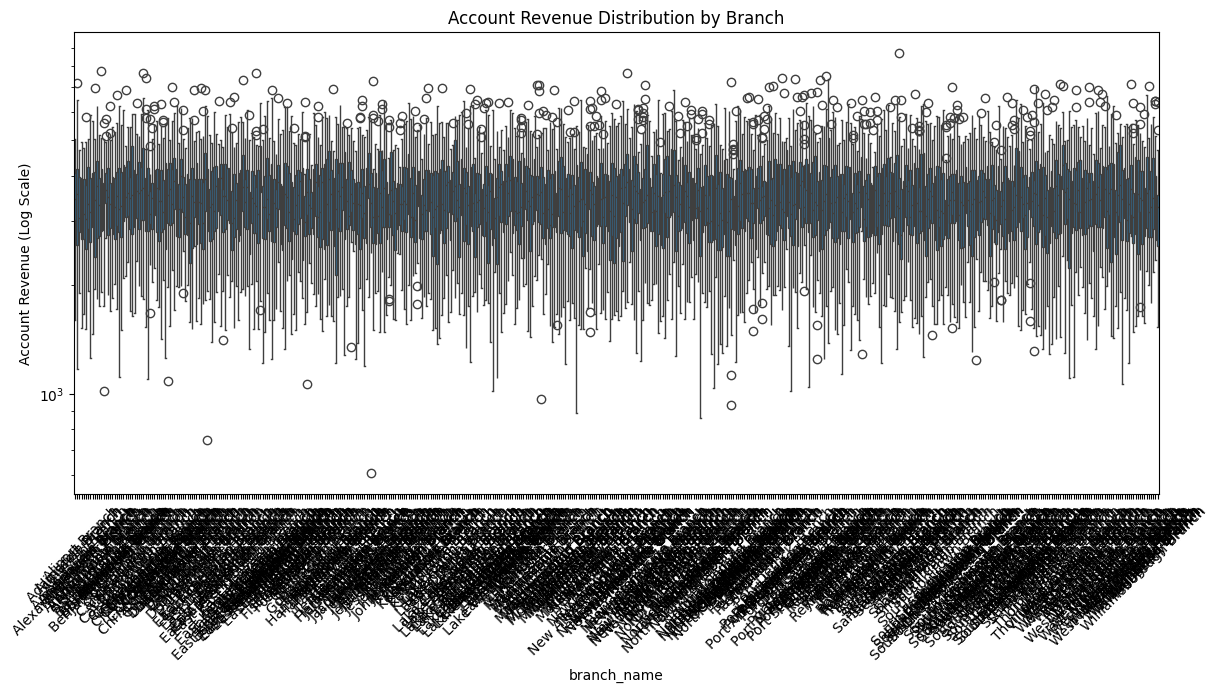

ANOVA F-Statistic: 1.0521
P-value: 2.0947e-01


In [4]:
query_branch = """
SELECT 
    b.branch_name,
    a.account_id,
    SUM(t.amount) as account_revenue
FROM fact_transactions t
JOIN dim_account a ON t.account_id = a.account_id
JOIN dim_branch b ON a.branch_id = b.branch_id
GROUP BY b.branch_name, a.account_id
"""
df_branch = pd.read_sql_query(query_branch, conn)
for col in df_branch.columns:
    if df_branch[col].dtype == 'object':
        try: df_branch[col] = pd.to_numeric(df_branch[col])
        except: pass
df_branch.fillna(0, inplace=True)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_branch, x='branch_name', y='account_revenue')
plt.title('Account Revenue Distribution by Branch')
plt.xticks(rotation=45)
plt.yscale('log') # Log scale for better visualization of skewed transaction data
plt.ylabel('Account Revenue (Log Scale)')
plt.savefig(f'{vis_dir}/revenue_by_branch_boxplot.png', bbox_inches='tight')
plt.show()

# Prepare data for ANOVA
groups = []
branch_names = df_branch['branch_name'].unique()
for branch in branch_names:
    groups.append(df_branch[df_branch['branch_name'] == branch]['account_revenue'].dropna())

# Perform One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")



**Business Interpretation:**
- **Null Hypothesis (H0):** The mean account revenue is the same across all branches.
- **Alternative Hypothesis (H1):** At least one branch has a different mean account revenue.

A significant p-value (< 0.05) indicates that location/branch plays a statistically significant role in revenue generation. This insight can drive strategic decisions, such as reallocating resources to high-performing branches, investigating underperforming branches for operational gaps, or tailoring branch-specific marketing strategies.
